# 14. Model Evaluation & Validation <a id="14-evaluation" name="14-evaluation"></a>

In [ ]:
# Metric 1: Genre consistency
def genre_consistency(input_title, recs_df):
    matched = fuzzy_match(input_title, title_to_idx)
    if not matched or recs_df is None: return 0
    idx = title_to_idx[matched]
    if isinstance(idx, pd.Series): idx = idx.iloc[0]
    inp_genres = set(str(df.iloc[idx]["genres"]).split(","))
    scores = []
    for _, row in recs_df.iterrows():
        rec_col = "Genre" if "Genre" in row.index else "primary_genre"
        genres_col = "genres" if "genres" in row.index else rec_col
        rec_g = set(str(row.get("Genre", row.get("primary_genre",""))).split(","))
        overlap = len(inp_genres & rec_g) / max(len(inp_genres), 1)
        scores.append(overlap)
    return np.mean(scores) if scores else 0


# Evaluate on top 30 popular films
top30 = df.nlargest(30, "vote_count")["title"].tolist()
consistency_scores = []
rating_scores = []
for t in top30:
    res = content_recommendations(t, n=5)
    if res:
        recs, _ = res
        consistency_scores.append(genre_consistency(t, recs))
        rating_scores.append(recs["Rating"].mean())

print(" CONTENT-BASED MODEL EVALUATION")
print("="*50)
print(f"  Tested on:              {len(top30)} popular films")
print(f"  Genre Consistency:      {np.mean(consistency_scores):.3f} (avg) | {np.min(consistency_scores):.3f} (min) | {np.max(consistency_scores):.3f} (max)")
print(f"  Avg Rec Rating:         {np.mean(rating_scores):.2f}")
print(f"  Dataset Avg Rating:     {df['vote_average'].mean():.2f}")
print(f"  Rating Uplift:          {np.mean(rating_scores) - df['vote_average'].mean():+.2f}")
print()

# Coverage
all_rec_titles = set()
for t in top30:
    res = content_recommendations(t, n=10)
    if res:
        recs, _ = res
        all_rec_titles.update(recs["Title"].tolist())
coverage = len(all_rec_titles) / len(df) * 100
print(f"  Catalog Coverage:       {coverage:.1f}% ({len(all_rec_titles)} unique films recommended)")

 CONTENT-BASED MODEL EVALUATION
  Tested on:              30 popular films
  Genre Consistency:      0.314 (avg) | 0.067 (min) | 0.500 (max)
  Avg Rec Rating:         7.12
  Dataset Avg Rating:     6.92
  Rating Uplift:          +0.20

  Catalog Coverage:       4.4% (232 unique films recommended)


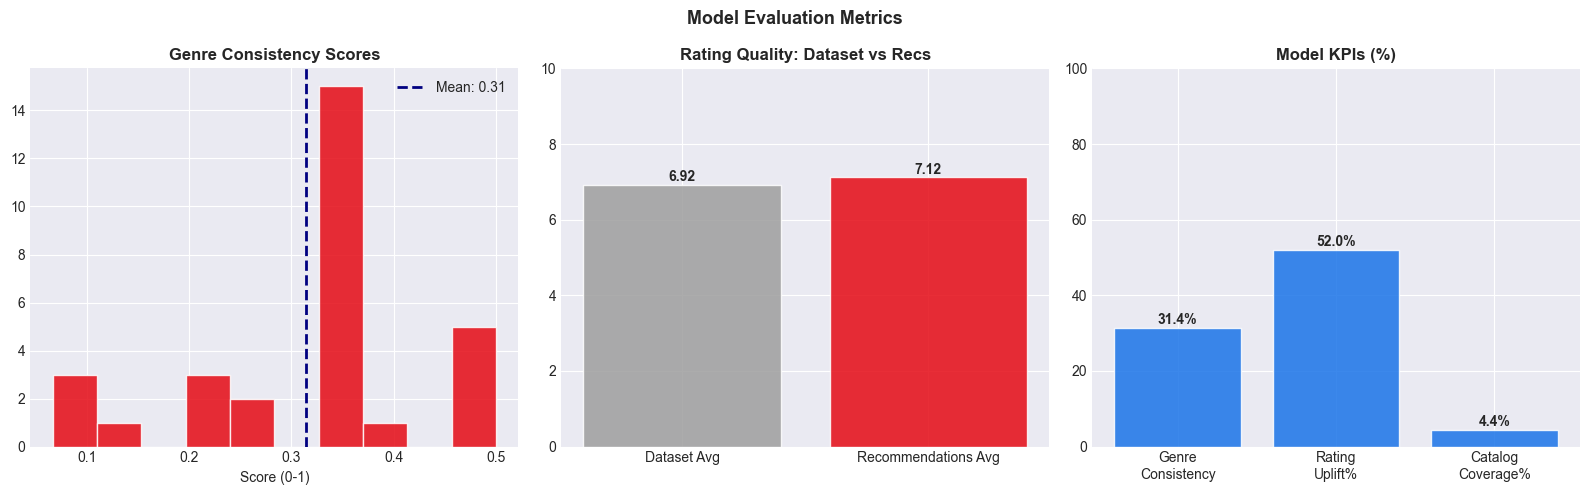

In [ ]:
# Evaluation visualisation
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Model Evaluation Metrics", fontsize=13, fontweight="bold")

axes[0].hist(consistency_scores, bins=10, color="#e50914", edgecolor="white", alpha=0.85)
axes[0].axvline(np.mean(consistency_scores), color="navy", linestyle="--", lw=2,
                label=f"Mean: {np.mean(consistency_scores):.2f}")
axes[0].set_title("Genre Consistency Scores", fontweight="bold")
axes[0].set_xlabel("Score (0-1)"); axes[0].legend()

cats = ["Dataset Avg", "Recommendations Avg"]
vals = [df["vote_average"].mean(), np.mean(rating_scores)]
axes[1].bar(cats, vals, color=["#9e9e9e","#e50914"], edgecolor="white", alpha=0.85)
axes[1].set_ylim(0, 10)
axes[1].set_title("Rating Quality: Dataset vs Recs", fontweight="bold")
for i, v in enumerate(vals):
    axes[1].text(i, v+0.1, f"{v:.2f}", ha="center", fontweight="bold")

metrics = ["Genre\nConsistency", "Rating\nUplift%", "Catalog\nCoverage%"]
vals2 = [np.mean(consistency_scores)*100,
         min(max((np.mean(rating_scores)-df["vote_average"].mean())/10*100+50, 0),100),
         coverage]
axes[2].bar(metrics, vals2, color="#1a73e8", edgecolor="white", alpha=0.85)
axes[2].set_title("Model KPIs (%)", fontweight="bold")
axes[2].set_ylim(0, 100)
for i, v in enumerate(vals2):
    axes[2].text(i, v+1, f"{v:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("../exports/fig_12_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
